In [2]:
#Libraries installation
!pip install -U scikit-learn
!pip install librosa matplotlib umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 45.2 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


Uploading dataset



In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

file_path = '/content/drive/My Drive/cse425/dataset_final.csv'  # Update path if needed
data = pd.read_csv(file_path)

mfcc_columns = [f'mfcc_{i}' for i in range(1, 14)]
mfcc_features = data[mfcc_columns]
print(mfcc_features.head())

      mfcc_1     mfcc_2     mfcc_3     mfcc_4     mfcc_5     mfcc_6  \
0 -172.53186  144.02585 -35.479717  14.106104  19.311249  -3.682629   
1 -218.08649  135.89520  13.833035  26.087866  10.417722  16.851640   
2 -156.04802   98.00602   3.610792  51.717052 -10.133570  -1.389707   
3 -337.14780  149.42995 -16.812240  -9.276005 -12.294240 -24.927448   
4 -374.50943  148.66824  45.411797  10.471763  16.143208   7.315037   

      mfcc_7     mfcc_8     mfcc_9    mfcc_10    mfcc_11    mfcc_12    mfcc_13  
0  -8.178381  -8.488638  -5.770176  -9.178972  -3.552192  -8.340675  -5.763819  
1   0.514010   5.958437  -4.732984   0.363632  -6.160233  -0.830772  -6.385419  
2  -8.393614  -8.649558 -12.110154  -3.660014 -10.354220 -10.654987 -17.185062  
3 -18.945805 -21.196707 -14.871328 -12.177295  -9.423781  -4.898274 -10.433724  
4  -0.023600   7.161666   5.094933  -5.190152  -5.411754  -2.784925  -6.797534  


In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap
from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Correlation Heatmap

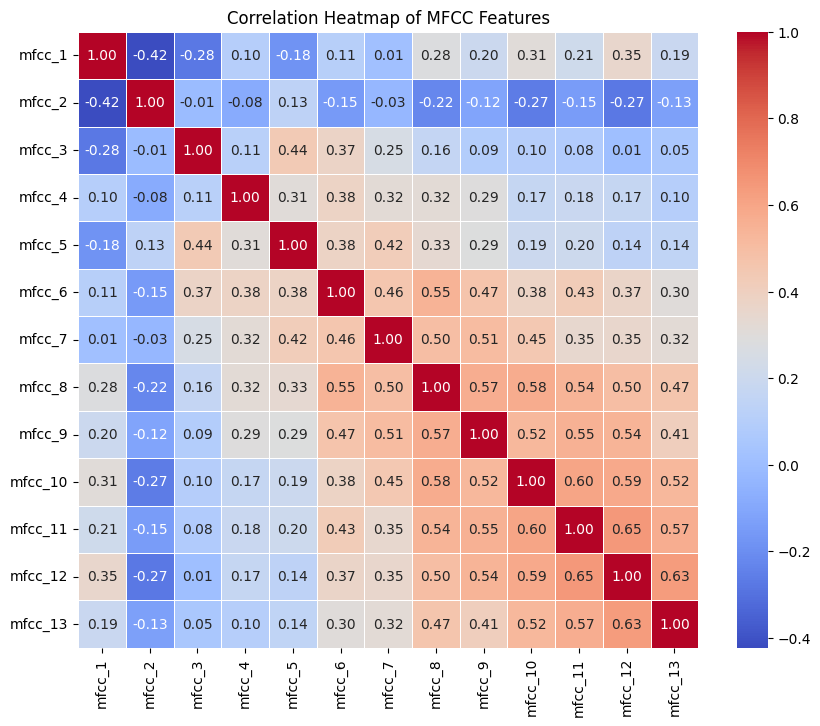

In [13]:
mfcc_columns = [f'mfcc_{i}' for i in range(1, 14)]
mfcc_features = data[mfcc_columns]

correlation_matrix = mfcc_features.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of MFCC Features')
plt.show()

In [14]:
scaler = StandardScaler()
mfcc_scaled = scaler.fit_transform(mfcc_features)

latent_dim = 2

class VAE(models.Model):
    def __init__(self, latent_dim, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.latent_dim = latent_dim

        self.encoder_dense_1 = layers.Dense(128, activation='relu')
        self.encoder_dense_2 = layers.Dense(64, activation='relu')
        self.z_mean = layers.Dense(latent_dim, name='z_mean')
        self.z_log_var = layers.Dense(latent_dim, name='z_log_var')

        self.decoder_dense_1 = layers.Dense(64, activation='relu')
        self.decoder_out = layers.Dense(mfcc_scaled.shape[1], activation='sigmoid')

    def call(self, inputs):
        x = self.encoder_dense_1(inputs)
        x = self.encoder_dense_2(x)
        z_mean = self.z_mean(x)
        z_log_var = self.z_log_var(x)

        z = self.sampling([z_mean, z_log_var])

        h_decoded = self.decoder_dense_1(z)
        x_decoded_mean = self.decoder_out(h_decoded)

        self.add_loss(self.vae_loss(inputs, x_decoded_mean, z_mean, z_log_var))

        return x_decoded_mean

    def sampling(self, args):
        z_mean, z_log_var = args
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    def vae_loss(self, inputs, x_decoded_mean, z_mean, z_log_var):
        xent_loss = mfcc_scaled.shape[1] * tf.keras.losses.binary_crossentropy(inputs, x_decoded_mean)

        kl_loss = - 0.5 * tf.reduce_mean(z_log_var - tf.square(z_mean) - tf.exp(z_log_var) + 1)

        return xent_loss + kl_loss

vae_model = VAE(latent_dim)
vae_model.compile(optimizer='rmsprop')
vae_model.fit(mfcc_scaled, epochs=50, batch_size=64)

Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 191.6425
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -5170.1377
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: -29933.5879
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: -103211.7500
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: -251868.5781
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -506803.6875
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: -1035426.0000
Epoch 8/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: -1791221.8750
Epoch 9/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: -2966727.0000
Epoch 10/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 171407360.0000
Epoch 11/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: -5910818.0000
Epoch 12/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: -8319750.5000
Epoch 13/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2112352384.0000
Epoch 14/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: -9036614.00

Latent_dim 1 to 8


In [26]:
input_shape = (13,)
inputs = layers.Input(shape=input_shape)

x = layers.Dense(64, activation='relu')(inputs)
x = layers.Dense(32, activation='relu')(x)
z = layers.Dense(8, name='z')(x)

encoder = models.Model(inputs, z)

latent_features = encoder.predict(mfcc_scaled)

latent_features_df = pd.DataFrame(latent_features, columns=['latent_dim_1', 'latent_dim_2' , 'latent_dim_3', 'latent_dim_4', 'latent_dim_5', 'latent_dim_6', 'latent_dim_7', 'latent_dim_8'])
print(latent_features_df.head())

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
   latent_dim_1  latent_dim_2  latent_dim_3  latent_dim_4  latent_dim_5  \
0      0.409513     -0.859077     -0.363410     -0.628011      0.076163   
1     -0.193505     -0.184199     -0.070381     -0.331737      0.199971   
2      0.031387     -0.223923     -0.512684     -0.721356     -0.157703   
3      0.700745     -0.858720     -0.467940     -0.865280     -0.528948   
4     -0.229936     -0.583129     -0.304963     -0.643356      0.212304   

   latent_dim_6  latent_dim_7  latent_dim_8  
0     -0.142244     -0.011794     -0.048507  
1     -0.331140      0.044815     -0.183049  
2      0.105778      0.164658      0.234965  
3      0.877225     -0.049018      0.222659  
4     -0.114122      0.052818     -0.120779  


Silhouette Score


In [27]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(latent_features)

sil_score = silhouette_score(latent_features, kmeans_labels)
print(f'Silhouette Score: {sil_score}')

Silhouette Score: 0.23877540230751038


TSNE PLOTTING


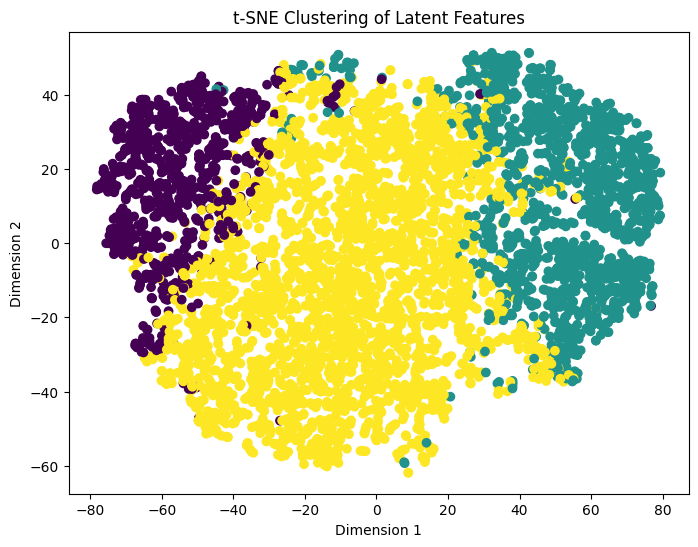

In [28]:
# import matplotlib.pyplot as plt
# from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
latent_2d = tsne.fit_transform(latent_features)

plt.figure(figsize=(8, 6))
plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=kmeans_labels, cmap='viridis', marker='o')
plt.title('t-SNE Clustering of Latent Features')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()

UMAP PLOTTING


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


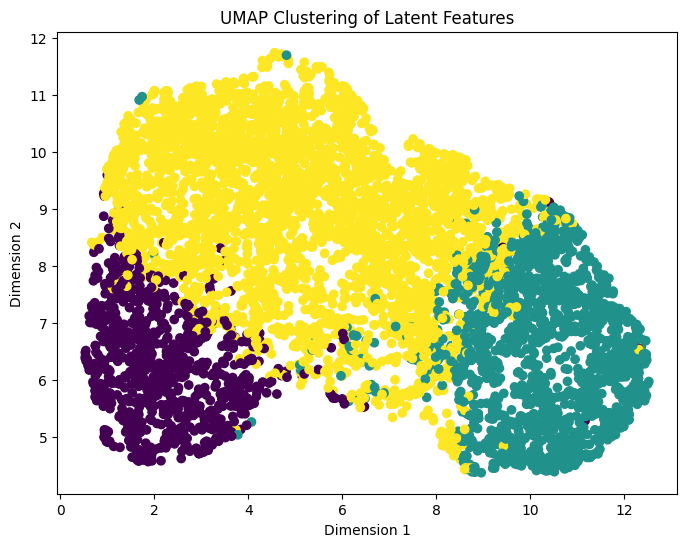

In [29]:
umap_model = umap.UMAP(n_components=2, random_state=42)
latent_2d_umap = umap_model.fit_transform(latent_features)

plt.figure(figsize=(8, 6))
plt.scatter(latent_2d_umap[:, 0], latent_2d_umap[:, 1], c=kmeans_labels, cmap='viridis', marker='o')
plt.title('UMAP Clustering of Latent Features')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()

PCA + K-MEANS Silhouette Score


In [30]:
pca = PCA(n_components=2, random_state=42)
latent_2d_pca = pca.fit_transform(latent_features)

kmeans_pca = KMeans(n_clusters=3, random_state=42)
kmeans_labels_pca = kmeans_pca.fit_predict(latent_2d_pca)


sil_score_pca = silhouette_score(latent_2d_pca, kmeans_labels_pca)
print(f'Silhouette Score (PCA + K-Means): {sil_score_pca}')

Silhouette Score (PCA + K-Means): 0.4369063973426819


PCA+ K-MEANS Clustering

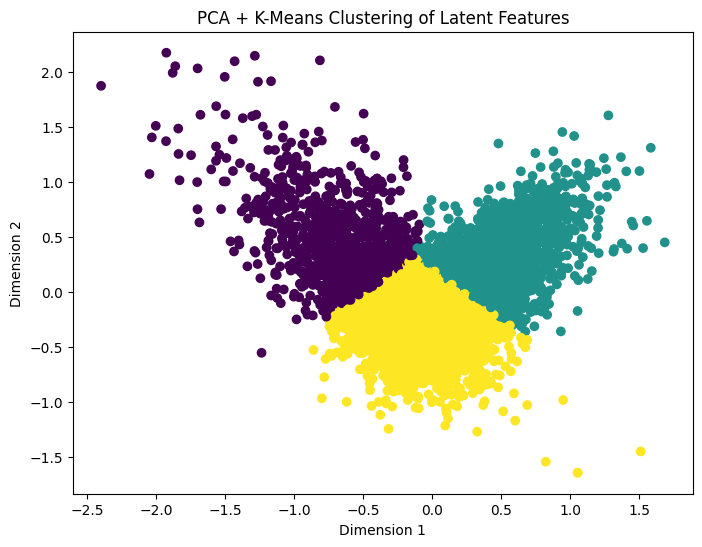

In [31]:
plt.figure(figsize=(8, 6))
plt.scatter(latent_2d_pca[:, 0], latent_2d_pca[:, 1], c=kmeans_labels_pca, cmap='viridis', marker='o')
plt.title('PCA + K-Means Clustering of Latent Features')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()

Calinski-Harabasz Index (PCA + K-Means)

In [32]:
ch_score_pca = calinski_harabasz_score(latent_2d_pca, kmeans_labels_pca)
print(f'Calinski-Harabasz Index (PCA + K-Means): {ch_score_pca}')


Calinski-Harabasz Index (PCA + K-Means): 5112.957172630784
